<a href="https://colab.research.google.com/github/suchithgali/pytorch_practice/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn #contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cpu'

In [ ]:
#creating parameters
weight = 0.5
bias = 0.1

# data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1100],
         [0.1200],
         [0.1300],
         [0.1400],
         [0.1500],
         [0.1600],
         [0.1700],
         [0.1800],
         [0.1900]]))

In [ ]:
len(X), len(y)

(50, 50)

In [ ]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [7]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions=None):

  """
  Plot training data, test data and compares predictions.
  """

  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14});

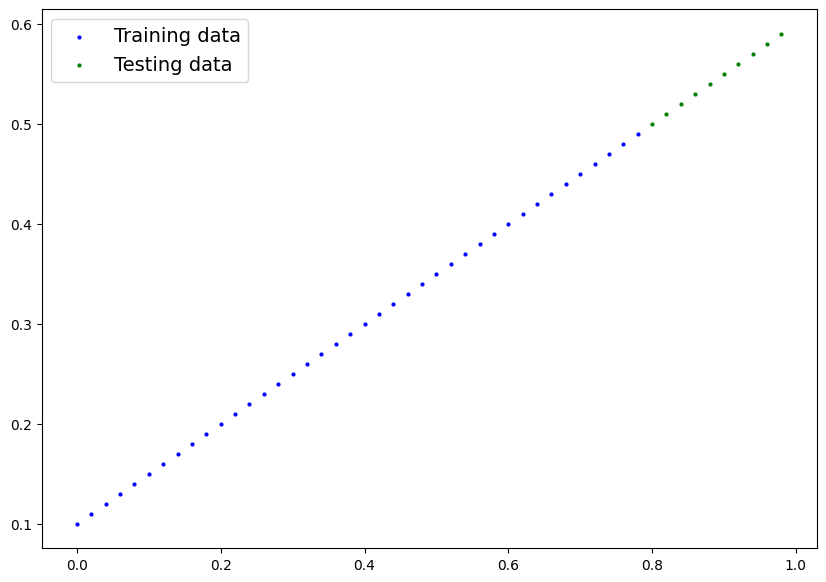

In [ ]:
plot_predictions();

In [10]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float)) #start with random values of size 1
    self.bias = nn.Parameter(torch.rand(1, requires_grad= True, dtype = torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias #linear regression

In [ ]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
#when making predictions use inference mode, inference mode doesn't save gradients
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [ ]:
y_test

tensor([[0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0.5500],
        [0.5600],
        [0.5700],
        [0.5800],
        [0.5900]])

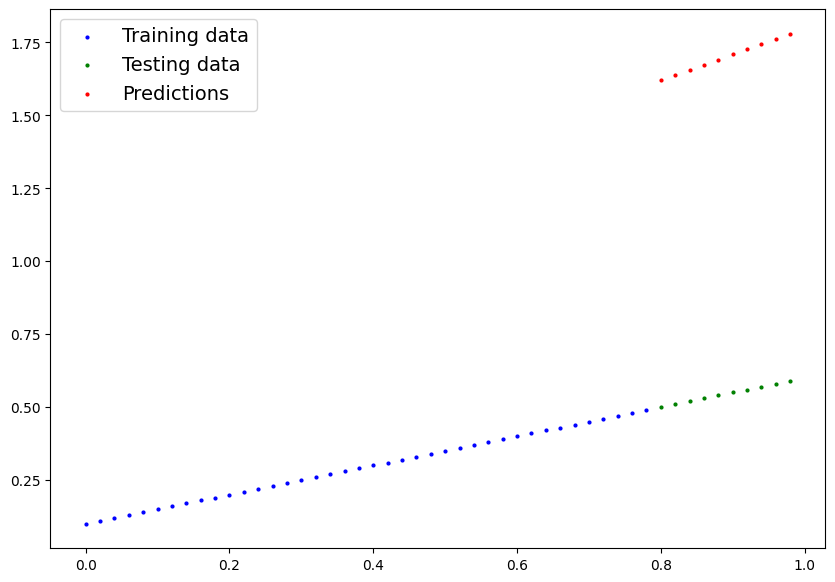

In [ ]:
plot_predictions(predictions = y_preds)

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [ ]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)

In [ ]:
epochs = 200 #one loop through the data

#tracking different values
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train() #set model to training mode, sets all parameters that require gradients to require gradients

  y_pred = model_0(X_train) #do forward propogation

  loss = loss_fn(y_pred, y_train) #calculate the loss

  optimizer.zero_grad() #optimizer zero grad

  loss.backward() #perform backpropogation

  optimizer.step() #perform gradient descent, the optimizer changes will accumulate so need to 0 them above for each loop

  # Evaluation and printing moved inside the loop to show progress
  model_0.eval() # turn off settings not needed for evaluation for inference
  with torch.inference_mode(): # turns off gradient tracking for inference
    test_pred = model_0(X_test) # do forward pass on test data
    test_loss = loss_fn(test_pred, y_test) # calculate loss on test data

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

# After the loop, the model remains in eval mode from the last iteration.
# If further training steps were to occur, it would be switched back to train mode.

Epoch: 0 | Train Loss: 0.9373 | Test Loss: 1.2748
Epoch: 10 | Train Loss: 0.5863 | Test Loss: 0.8046
Epoch: 20 | Train Loss: 0.3667 | Test Loss: 0.5090
Epoch: 30 | Train Loss: 0.2294 | Test Loss: 0.3229
Epoch: 40 | Train Loss: 0.1435 | Test Loss: 0.2055
Epoch: 50 | Train Loss: 0.0898 | Test Loss: 0.1314
Epoch: 60 | Train Loss: 0.0562 | Test Loss: 0.0844
Epoch: 70 | Train Loss: 0.0352 | Test Loss: 0.0546
Epoch: 80 | Train Loss: 0.0220 | Test Loss: 0.0356
Epoch: 90 | Train Loss: 0.0138 | Test Loss: 0.0234
Epoch: 100 | Train Loss: 0.0087 | Test Loss: 0.0155
Epoch: 110 | Train Loss: 0.0055 | Test Loss: 0.0105
Epoch: 120 | Train Loss: 0.0034 | Test Loss: 0.0072
Epoch: 130 | Train Loss: 0.0022 | Test Loss: 0.0050
Epoch: 140 | Train Loss: 0.0014 | Test Loss: 0.0035
Epoch: 150 | Train Loss: 0.0009 | Test Loss: 0.0026
Epoch: 160 | Train Loss: 0.0006 | Test Loss: 0.0019
Epoch: 170 | Train Loss: 0.0004 | Test Loss: 0.0014
Epoch: 180 | Train Loss: 0.0003 | Test Loss: 0.0011
Epoch: 190 | Train Loss

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5381])), ('bias', tensor([0.0933]))])

In [ ]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)


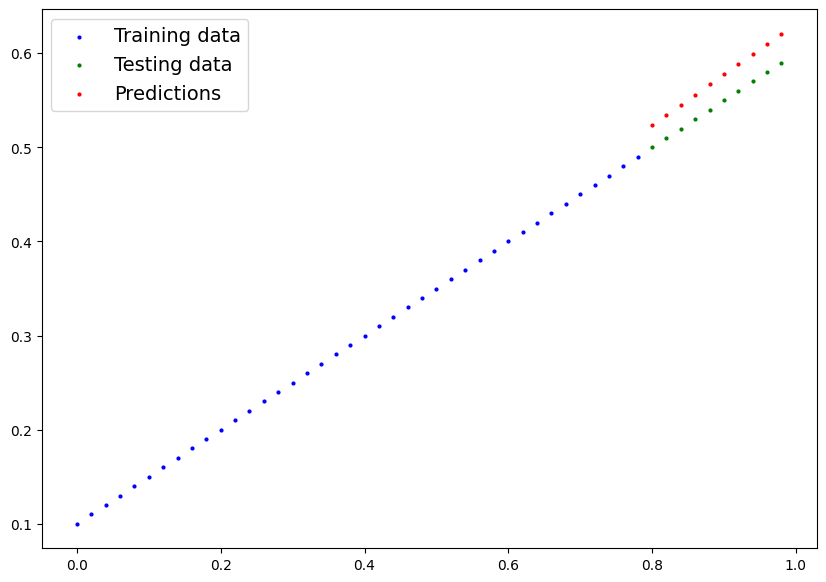

In [ ]:
  plot_predictions(predictions=y_pred_new)

/tmp/ipython-input-3440014459.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = 'Train Loss')


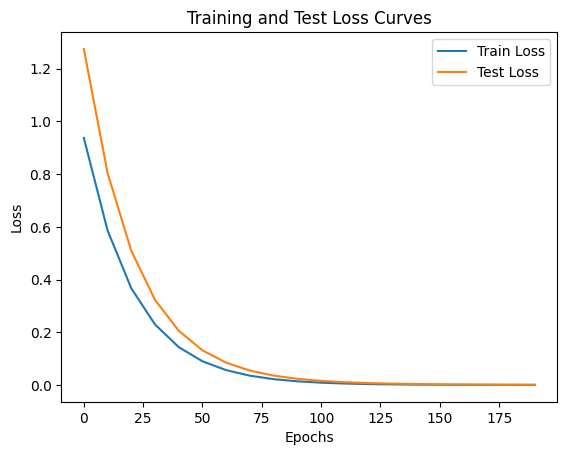

In [ ]:
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = 'Train Loss')
plt.plot(epoch_count, test_loss_values, label = 'Test Loss')
plt.title('Training and Test Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Feb 23 07:57 01_pytorch_workflow_model_0.pth


In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5381])), ('bias', tensor([0.0933]))])

In [ ]:
loaded_model_0 = LinearRegressionModel() #creating new instance

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH)) #on the instance we are loading the previous model

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.5381])), ('bias', tensor([0.0933]))])

In [ ]:
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.5238],
        [0.5346],
        [0.5453],
        [0.5561],
        [0.5669],
        [0.5776],
        [0.5884],
        [0.5992],
        [0.6099],
        [0.6207]])

In [ ]:
model_0.eval()

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds



tensor([[0.5238],
        [0.5346],
        [0.5453],
        [0.5561],
        [0.5669],
        [0.5776],
        [0.5884],
        [0.5992],
        [0.6099],
        [0.6207]])

In [ ]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__



'2.10.0+cpu'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")



Using device: cpu


In [4]:
weight = 0.5
bias = 0.2

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y [:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2000],
         [0.2100],
         [0.2200],
         [0.2300],
         [0.2400],
         [0.2500],
         [0.2600],
         [0.2700],
         [0.2800],
         [0.2900]]))

In [5]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

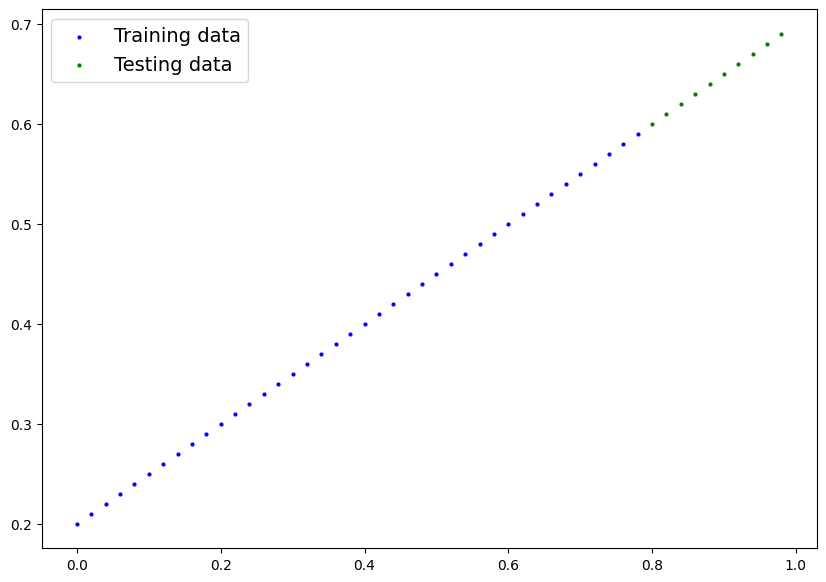

In [8]:
plot_predictions(X_train, y_train, X_test, y_test)

In [13]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #use nn.Linear() for creating the model parameters also called fully connected layer
    self.linear_layer = nn.Linear(in_features = 1, out_features = 1) #input of size 1 and output of size 1

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [15]:
torch.manual_seed(43)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[-0.0921]])),
              ('linear_layer.bias', tensor([-0.6070]))]))